In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import pingouin as pg
import matplotlib.pyplot as plt
import matplotlib

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:.6f}'.format

matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 


df = pd.read_csv("participants_info.csv", delimiter=",")
df_mod = pd.read_csv("modalities_info.csv", delimiter=",")[["participant_id", "session", "anat", "fmri", "dwi"]].drop_duplicates(subset="participant_id", keep="first")
df = pd.merge(df, df_mod, on = "participant_id", how="left")
# Assume df is your dataframe

# 2. Map group codes to labels
group_map = {
    0: "HC",
    0.1: "HC Sibling",
    1: "SCHZ",
    1.1: "SCHZ Sibling",
    2: "BD",
    3: "FEP",
    4: "MDD",
    5: "CHR",
    6: "ADHD",
    7: "PTSD",
    8: "GAD",
    9: "SAD",
    10: "SUD",
    11: "OCD",
    12: "SEAD",
    13: "ASD",
    14: "CPS",
    15: "Stroke",
    16: "BPD",
    17: "ARMS",
    18: "AN",
    19: "WR",
    20: "AUD",
    21: "Panic Episode",
    22: "Agoraphobia"
}

# Keep only one row per participant
df_unique = df.copy()

# Split ONLY entries that contain ';'
df_unique["group_split"] = df_unique["group"].astype(str).str.split(";")

# Expand multiple-group participants into multiple rows
df_exploded = df_unique.explode("group_split")

# Convert to numeric (preserves 0.1, 1.1, etc.)
df_exploded["group_split"] = pd.to_numeric(
    df_exploded["group_split"].str.strip(),
    errors="coerce"
)

# Map codes to labels
df_exploded["group_label"] = df_exploded["group_split"].map(group_map)

# Count participants in each group
counts = df_exploded["group_label"].value_counts()

# Percentage relative to total unique participants
n_participants = df_unique["participant_id"].nunique()

percentages = counts / n_participants * 100

result = pd.DataFrame({
    "count": counts,
    "percentage": percentages
}).sort_values("count", ascending=False)

print(result)

               count  percentage
group_label                     
HC              4878   57.213230
SCHZ            1147   13.452967
MDD              786    9.218860
ADHD             322    3.776683
GAD              246    2.885292
BD               243    2.850106
ASD              127    1.489561
SUD              125    1.466104
HC Sibling        87    1.020408
CHR               81    0.950035
SCHZ Sibling      79    0.926578
CPS               67    0.785832
WR                58    0.680272
AN                58    0.680272
ARMS              52    0.609899
PTSD              49    0.574713
Panic Episode     47    0.551255
BPD               46    0.539526
FEP               41    0.480882
AUD               41    0.480882
SAD               31    0.363594
OCD               27    0.316678
Agoraphobia       18    0.211119
Stroke            10    0.117288
SEAD               1    0.011729


In [3]:
total_participants = df_unique["participant_id"].nunique()

print(f"Total participants: {total_participants}")

Total participants: 8526


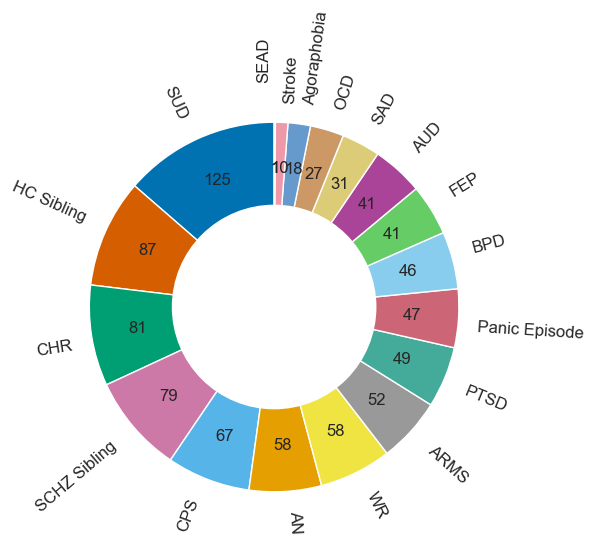

In [48]:
sns.set(style="white")

# Remove HC
df_no_hc = df_exploded[df_exploded["group_label"] != "HC"].copy()

# Rename labels
rename_map = {
    "SCHZ": "SSD",
}
df_no_hc["group_label"] = df_no_hc["group_label"].replace(rename_map)

# Counts
diag_counts = df_no_hc["group_label"].value_counts().sort_values(ascending=False)

# Define top N
top_n = 6

# Categories that were grouped into "Other"
other_counts = diag_counts.iloc[top_n:]

# Plot only the "Other" diagnoses
plt.figure(figsize=(6, 6))

colors = [
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#009E73",  # bluish green
    "#CC79A7",  # reddish purple
    "#56B4E9",  # sky blue
    "#E69F00",  # orange
    "#F0E442",  # yellow
    "#999999",  # grey
    "#44AA99",  # turquoise
    "#CC6677",  # muted rose
    "#88CCEE",  # light cyan
    "#66CC66",  # light green
    "#AA4499",  # purple
    "#DDCC77",  # sand
    "#CC9966",  # tan
    "#6699CC",  # steel blue
    "#EE99AA",  # light rose
    "#55AA55",  # emerald green
    "#EE6677",  # coral
    "#FFB000",  # amber
    "#77AADD",  # light blue
    "#FFA07A",  # salmon
    "#A1D99B",  # pastel green
    "#C994C7",  # lavender
]

def autopct_counts(values):
    def inner(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f"{count}"
    return inner

wedges, texts, autotexts = plt.pie(
    other_counts,
    labels=other_counts.index,
    autopct=autopct_counts(other_counts),
    startangle=90,
    colors=colors[:len(other_counts)],
    pctdistance=0.75,
    rotatelabels=True,
    textprops={"fontsize": 12}
)

# Push tiny slices further out
for w, t, count in zip(wedges, texts, other_counts):
    if count < 10:  # adjust threshold
        x, y = t.get_position()
        t.set_position((1 * x-0.1, 1.1 * y))

centre_circle = plt.Circle((0, 0), 0.55, fc="white")
plt.gca().add_artist(centre_circle)


plt.savefig("figs4.1.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [47]:
import os
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

sns.set(style="white")

# -----------------------------
# OUTPUT FOLDER
# -----------------------------
out_dir = "other_group_kdes"
os.makedirs(out_dir, exist_ok=True)

# -----------------------------
# REMOVE HC
# -----------------------------
df_no_hc = df_exploded[
    (df_exploded["group_label"].notna()) &
    (df_exploded["group_label"] != "HC")
].copy()

# -----------------------------
# RENAME LABELS
# -----------------------------
df_no_hc["group_label"] = df_no_hc["group_label"].replace({"SCHZ": "SSD"})

# Avoid duplicate participant within same group
df_no_hc = df_no_hc.drop_duplicates(
    subset=["participant_id", "group_label"],
    keep="first"
)

# -----------------------------
# OTHER GROUPS
# -----------------------------
group_counts = df_no_hc["group_label"].value_counts()

top_n = 6
other_groups = group_counts.iloc[top_n:].index

df_other = df_no_hc[df_no_hc["group_label"].isin(other_groups)].copy()

# -----------------------------
# SEX MAP
# -----------------------------
sex_map = {0: "Female", 1: "Male"}

# -----------------------------
# COLORS
# -----------------------------
colors = [
    "#0072B2", "#D55E00", "#009E73", "#CC79A7",
    "#56B4E9", "#E69F00", "#F0E442", "#999999",
    "#44AA99", "#CC6677", "#88CCEE", "#66CC66",
    "#AA4499", "#DDCC77", "#CC9966", "#6699CC",
    "#EE99AA", "#55AA55", "#EE6677", "#FFB000",
    "#77AADD", "#FFA07A", "#A1D99B", "#C994C7",
]

# -----------------------------
# SAFE FILE NAME FUNCTION
# -----------------------------
def safe_filename(name):
    name = str(name)
    name = re.sub(r"[^A-Za-z0-9_\-]+", "_", name)
    return name.strip("_")

# -----------------------------
# ONE SMALL KDE PER OTHER GROUP
# -----------------------------
for i, group in enumerate(other_groups):
    subset = df_other[df_other["group_label"] == group].copy()

    ages = pd.to_numeric(subset["age"], errors="coerce").dropna()

    if len(ages) < 2:
        continue

    color = colors[i % len(colors)]

    fig, ax = plt.subplots(figsize=(4.5, 3))

    sns.kdeplot(
        ages,
        fill=True,
        linewidth=2,
        color=color,
        label=group,
        alpha=0.2,
        ax=ax
    )

    mean_age = ages.mean()
    std_age = ages.std()

    kde = gaussian_kde(ages)
    y_mean = kde(mean_age)[0]

    ax.plot(
        [mean_age, mean_age],
        [0, y_mean],
        color=color,
        linestyle="--",
        linewidth=2
    )

    sex_clean = pd.to_numeric(subset["sex"], errors="coerce")
    sex = sex_clean.map(sex_map).dropna()
    sex_pct = sex.value_counts(normalize=True) * 100
    female_pct = sex_pct.get("Female", 0)

    # Legend instead of title
    ax.legend(
        fontsize=9,
        loc="upper right",
        frameon=True
    )

    # Text inset inside graph
    stats_text = (
        f"{mean_age:.1f} [{std_age:.1f}] yrs\n"
        f"{female_pct:.1f}% female\n"
        f"N = {len(ages)}"
    )

    ax.text(
        0.97,
        0.72,
        stats_text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8,
        color=color,
        fontweight="bold",
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            edgecolor=color,
            alpha=0.9
        )
    )

    ax.set_xlabel("Age (years)", fontsize=10)
    ax.set_ylabel("Density", fontsize=10)

    ax.set_xticks(np.arange(0, 81, 20))
    ax.set_xlim(0, 80)
    ax.set_ylim(bottom=0)

    ax.tick_params(axis="both", labelsize=8)
    ax.grid(True)

    plt.tight_layout()

    filename = f"figs4.2_{i+1:02d}_{safe_filename(group)}.pdf"
    filepath = os.path.join(out_dir, filename)

    plt.savefig(filepath, format="pdf", bbox_inches="tight")
    plt.close()

#### print(list(other_groups))